In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scanpy as sc
import gseapy
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
lib = '2'
BC = 'BC004'

adata_dir = large_data_dir + 'MPN_WTA/MPN_' + lib + '_' + BC + '_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)


In [4]:
DE = pd.read_csv('../data/MPL_RUNX1_vs_MPL_PTPN11_DE_2_BC004.csv', index_col=0)
pre_res = gseapy.prerank(DE.loc[:,['primerid', 'coef']], gene_sets='MSigDB_Hallmark_2020', verbose=True)
res = pre_res.res2d.copy()

2026-04-12 17:42:31,729 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-12 17:42:31,737 [INFO] Parsing data files for GSEA.............................
2026-04-12 17:42:31,746 [INFO] Enrichr library gene sets already downloaded in: /home/blattms1/.cache/gseapy, use local file
2026-04-12 17:42:31,753 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-12 17:42:31,753 [INFO] 0049 gene_sets used for further statistical testing.....


2026-04-12 17:42:31,753 [INFO] Start to run GSEA...Might take a while..................
2026-04-12 17:42:32,643 [INFO] Congratulations. GSEApy runs successfully................



TNF-alpha Signaling via NF-kB
Inflammatory Response
['KLF2' 'KLF6' 'CD44' 'JUNB' 'MCL1' 'FOS' 'NR4A2' 'EGR1' 'RHOB' 'IER2']
Oxidative Phosphorylation
Bile Acid Metabolism
['ALDH1A1' 'ABCA5' 'LDHB' 'RXRA' 'TIMM13' 'NDUFS2' 'FADS2' 'ATP5F1A'
 'PFKM' 'ECH1']


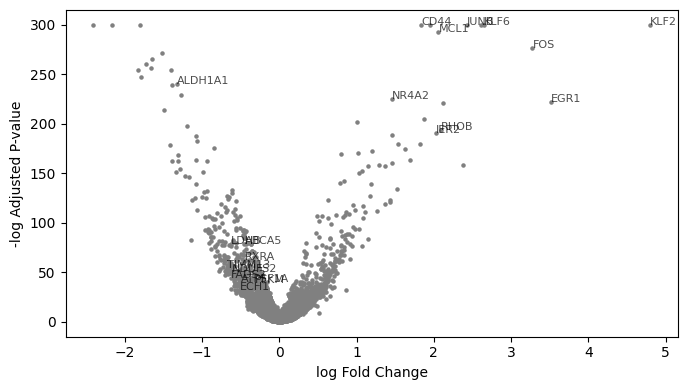

In [5]:
s=10
df = DE.copy()

df['Pr(>Chisq)'] = df['Pr(>Chisq)'] + (1e-300)
fig,ax = plt.subplots(figsize=(7,4))
ax.scatter(df['coef'], -np.log10(df['Pr(>Chisq)']), s=5, color='grey')

pathway_genes = res.sort_values('NES', ascending=False).iloc[0]['Lead_genes'].split(';')
pathway_genes.extend(res.sort_values('NES', ascending=False).iloc[2]['Lead_genes'].split(';'))
pathway_genes = list(set(pathway_genes))

print(res.sort_values('NES', ascending=False).iloc[0]['Term'])
print(res.sort_values('NES', ascending=False).iloc[1]['Term'])

pathway_genes = df.loc[df['primerid'].isin(pathway_genes)].sort_values(['Pr(>Chisq)','coef'], ascending=[True,False]).iloc[0:10]['primerid'].values
print(pathway_genes)
for gene in pathway_genes:
    sub = df.loc[df['primerid'] == gene]
    ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7)

### now plot downregulated genes
pathway_genes = res.sort_values('NES', ascending=True).iloc[0]['Lead_genes'].split(';')
pathway_genes.extend(res.sort_values('NES', ascending=True).iloc[1]['Lead_genes'].split(';'))
pathway_genes = list(set(pathway_genes))

print(res.sort_values('NES', ascending=True).iloc[0]['Term'])
print(res.sort_values('NES', ascending=True).iloc[1]['Term'])

pathway_genes = df.loc[df['primerid'].isin(pathway_genes)].sort_values(['Pr(>Chisq)','coef'], ascending=[True,True]).iloc[0:10]['primerid'].values
print(pathway_genes)
for gene in pathway_genes:
    sub = df.loc[df['primerid'] == gene]
    ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7)


ax.set_xlabel('log Fold Change')
ax.set_ylabel('-log Adjusted P-value')
plt.tight_layout()
plt.savefig('../plots/volcano_BC004_2.pdf')


In [6]:
res.sort_values('NES', ascending=False)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,TNF-alpha Signaling via NF-kB,0.814472,2.788163,0.0,0.0,0.0,81/166,9.93%,KLF2;EGR1;FOS;KLF6;JUNB;FOSB;RHOB;MCL1;IER2;CD...
1,prerank,Inflammatory Response,0.584214,1.958558,0.0,0.0,0.0,41/139,10.00%,KLF6;CD69;LY6E;RHOG;PTPRE;NFKBIA;CD55;IRF1;EMP...
2,prerank,UV Response Up,0.590165,1.922199,0.0,0.000908,0.002,26/123,8.30%,FOS;JUNB;FOSB;RHOB;ATF3;CXCL2;PPIF;DNAJA1;EIF5...
3,prerank,Hypoxia,0.55696,1.847779,0.0,0.002725,0.008,36/145,10.04%,FOS;KLF6;ZFP36;ATF3;DUSP1;PPP1R15A;PDK1;MAFF;B...
4,prerank,Epithelial Mesenchymal Transition,0.560712,1.816799,0.0,0.00327,0.012,21/108,4.93%,RHOB;CD44;SAT1;SPARC;VIM;FLNA;TPM4;ANPEP;EMP3;...
5,prerank,Apoptosis,0.545965,1.80357,0.0,0.003179,0.014,42/132,11.78%,RHOB;MCL1;CD44;ATF3;SAT1;CD69;CD38;H1-0;HGF;DN...
7,prerank,IL-6/JAK/STAT3 Signaling,0.57423,1.71768,0.002387,0.008563,0.044,23/69,14.85%,CD44;CD38;IL3RA;IRF1;JUN;MAP3K8;CSF3R;CBL;CXCL...
8,prerank,TGF-beta Signaling,0.606543,1.699432,0.004751,0.008685,0.051,19/44,13.67%,JUNB;PPP1R15A;KLF10;TGIF1;CDK9;PPM1A;RHOA;FURI...
10,prerank,IL-2/STAT5 Signaling,0.484408,1.635573,0.0,0.014683,0.092,39/155,9.49%,KLF6;RHOB;CD44;MAFF;BHLHE40;BCL2;NFIL3;IL3RA;N...
12,prerank,p53 Pathway,0.473589,1.616505,0.0,0.014849,0.103,34/169,8.60%,FOS;S100A10;ATF3;SAT1;PPP1R15A;IER5;H1-2;S100A...
